In [38]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [39]:
df = pd.read_excel(r"C:\Users\Amey\Desktop\Amey\Python\101\101_Pre_done_Combined.xlsx")

df.head()

,Material,SLoc,Quantity,Pstng Date,order,Equipment,Technician name,Year,Tavg,Tmax,Tmin,RH,Month,Season,Delta_T,Region,Location
0,101,5001,-1,2020-03-02,48752021,10952011,Mathanram Muthukutty,2020,26.89,34.83,21.23,54.32,3,Summer,13.60,West1,Mumbai
1,101,5001,-1,2020-04-24,48885258,10889443,Shashank Pawar,2020,31.38,38.35,25.87,57.91,4,Summer,12.48,West1,Mumbai
2,101,5005,-1,2020-07-06,49095741,10938439,Janeshwar Channa,2020,28.42,31.40,26.74,83.74,7,Monsoon,4.66,West2,Ahmedabad
3,101,5021,-1,2020-07-20,49144835,10889064,Yogesh Saini,2020,33.67,38.55,29.27,61.08,7,Monsoon,9.28,North1,Delhi
4,101,5003,-1,2020-07-28,49163605,11157454,Anil Surwase,2020,23.81,26.40,21.68,91.92,7,Monsoon,4.72,West1,Pune


In [40]:
df['Pstng Date'] = pd.to_datetime(df['Pstng Date'])

df['Consumption'] = abs(df['Quantity'])

india = (
    df.groupby(
        pd.Grouper(
            key='Pstng Date',
            freq='MS'
        )
    )
    .agg({
        'Consumption':'sum',
        'Tavg':'mean',
        'Tmax':'mean',
        'Tmin':'mean',
        'RH':'mean',
        'Delta_T':'mean'
    })
    .reset_index()
)

india.head()

,Pstng Date,Consumption,Tavg,Tmax,Tmin,RH,Delta_T
0,2020-03-01,1,26.890000,34.830000,21.230000,54.320000,13.60
1,2020-04-01,1,31.380000,38.350000,25.870000,57.910000,12.48
2,2020-05-01,0,NaN,NaN,NaN,NaN,NaN
3,2020-06-01,0,NaN,NaN,NaN,NaN,NaN
4,2020-07-01,3,28.633333,32.116667,25.896667,78.913333,6.22


In [41]:
india['Month'] = india['Pstng Date'].dt.month
india['Quarter'] = india['Pstng Date'].dt.quarter

india['month_sin'] = np.sin(
    2 * np.pi * india['Month'] / 12
)

india['month_cos'] = np.cos(
    2 * np.pi * india['Month'] / 12
)
# Lag Features
for lag in [1,2,3,6,12]:
    india[f'lag_{lag}'] = india['Consumption'].shift(lag)

# Rolling Features
india['roll_mean_3'] = (
    india['Consumption']
    .shift(1)
    .rolling(3)
    .mean()
)

india['roll_mean_6'] = (
    india['Consumption']
    .shift(1)
    .rolling(6)
    .mean()
)

india['roll_std_3'] = (
    india['Consumption']
    .shift(1)
    .rolling(3)
    .std()
)
india['roll_mean_12'] = (
    india['Consumption']
    .shift(1)
    .rolling(12)
    .mean()
)

india['roll_std_12'] = (
    india['Consumption']
    .shift(1)
    .rolling(12)
    .std()
)

india = india.dropna()

india.head()

,Pstng Date,Consumption,Tavg,Tmax,Tmin,RH,Delta_T,Month,Quarter,month_sin,...,lag_1,lag_2,lag_3,lag_6,lag_12,roll_mean_3,roll_mean_6,roll_std_3,roll_mean_12,roll_std_12
12,2021-03-01,1,30.44,39.400000,23.400000,32.96,16.00,3,1,1.000000e+00,...,3.0,4.0,0.0,3.0,1.0,2.333333,2.000000,2.081666,1.500000,1.445998
13,2021-04-01,1,28.90,37.330000,23.050000,58.85,14.28,4,2,8.660254e-01,...,1.0,3.0,4.0,2.0,1.0,2.666667,1.666667,1.527525,1.500000,1.445998
14,2021-05-01,1,34.56,40.680000,28.770000,24.96,11.91,5,2,5.000000e-01,...,1.0,1.0,3.0,0.0,0.0,1.666667,1.500000,1.154701,1.500000,1.445998
15,2021-06-01,3,32.84,38.326667,27.676667,56.93,10.65,6,2,1.224647e-16,...,1.0,1.0,1.0,0.0,0.0,1.000000,1.666667,0.000000,1.583333,1.378954
17,2021-08-01,3,28.56,32.670000,25.280000,82.74,7.39,8,3,-8.660254e-01,...,0.0,3.0,1.0,3.0,1.0,1.333333,1.500000,1.527525,1.583333,1.378954


In [42]:
train = india[
    india['Pstng Date'] < '2025-01-01'
]

test = india[
    india['Pstng Date'] >= '2025-01-01'
]

print(train.shape)
print(test.shape)

(42, 21)
(16, 21)


In [43]:
FEATURES = [

    'month_sin',
    'month_cos',
    'Quarter',

    'lag_1',
    'lag_2',
    'lag_3',
    'lag_6',
    'lag_12',

    'roll_mean_3',
    'roll_mean_6',
    'roll_std_3',
    'roll_std_12',
    'roll_mean_12',

    'Tavg',
    'Tmax',
    'Tmin',
    'RH',
    'Delta_T'
]

TARGET = 'Consumption'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]


def evaluate_model(y_true,y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mape = np.mean(
        np.abs(
            (y_true-y_pred)/y_true
        )
    )*100

    wape = (
        np.sum(np.abs(y_true-y_pred))
        /
        np.sum(y_true)
    )*100

    return mae,rmse,mape,wape

In [44]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [45]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

In [46]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=5,
    max_depth=3,
    min_child_samples=5,
    random_state=42,
    verbosity=-1
)

lgbm.fit(X_train,y_train)

lgbm_pred = lgbm.predict(X_test)

In [47]:
cat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    random_seed=42,
    verbose=False
)

cat.fit(X_train,y_train)

cat_pred = cat.predict(X_test)

In [56]:
exog_train = train[
    [
        'Tavg',
        'Tmax',
        'Tmin',
        'RH',
        'Delta_T'
    ]
]

exog_test = test[
    [
        'Tavg',
        'Tmax',
        'Tmin',
        'RH',
        'Delta_T'
    ]
]
sarimax = SARIMAX(
    y_train,
    exog=exog_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarimax_fit = sarimax.fit(disp=False)

sarimax_pred = sarimax_fit.forecast(
    len(test),
    exog=exog_test
)

In [49]:
results = []

models = {
    'RandomForest':rf_pred,
    'XGBoost':xgb_pred,
    'LightGBM':lgbm_pred,
    'CatBoost':cat_pred,
    'SARIMAX':sarimax_pred
}

for model_name,preds in models.items():

    mae,rmse,mape,wape = evaluate_model(
        y_test,
        preds
    )

    results.append([
        model_name,
        mae,
        rmse,
        mape,
        wape
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'MAPE',
        'WAPE'
    ]
)

results_df.sort_values(
    'WAPE'
)

,Model,MAE,RMSE,MAPE,WAPE
4,SARIMAX,4.584908,6.192925,NaN,0.000000
1,XGBoost,2.935952,3.850065,107.222940,51.060038
3,CatBoost,2.937810,3.662766,91.458260,51.092344
0,RandomForest,3.057125,3.977120,111.820499,53.167391
2,LightGBM,3.103738,4.250656,105.935402,53.978054


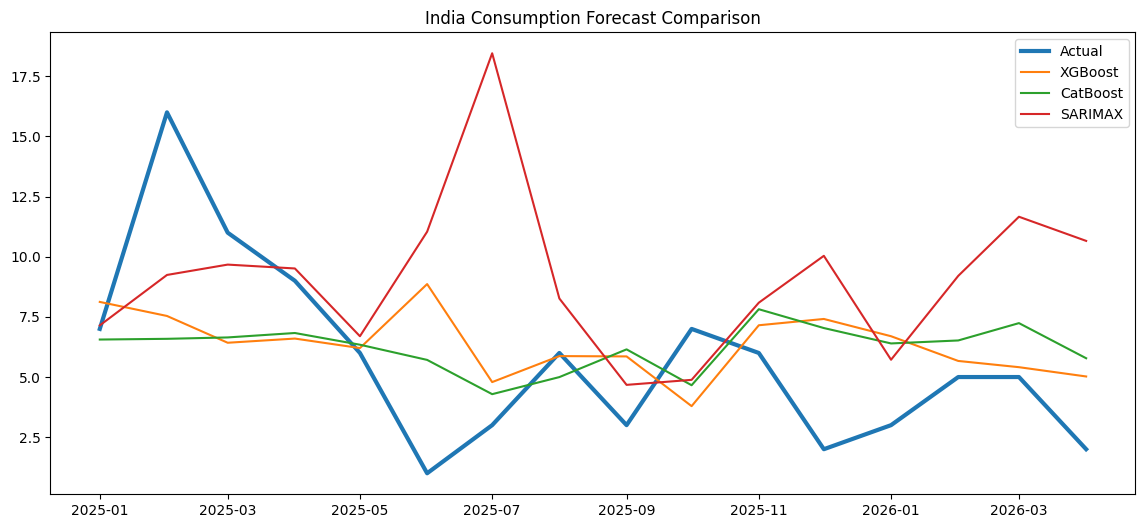

In [50]:
plt.figure(figsize=(14,6))

plt.plot(
    test['Pstng Date'],
    y_test,
    label='Actual',
    linewidth=3
)

plt.plot(
    test['Pstng Date'],
    xgb_pred,
    label='XGBoost'
)

plt.plot(
    test['Pstng Date'],
    cat_pred,
    label='CatBoost'
)

plt.plot(
    test['Pstng Date'],
    sarimax_pred,
    label='SARIMAX'
)

plt.legend()

plt.title(
    "India Consumption Forecast Comparison"
)

plt.show()

In [51]:
importance = pd.DataFrame({
    'Feature':FEATURES,
    'Importance':xgb.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

importance

,Feature,Importance
3,lag_1,0.176320
7,lag_12,0.121261
11,roll_std_12,0.096583
16,RH,0.087426
10,roll_std_3,0.074717
13,Tavg,0.072905
15,Tmin,0.056302
8,roll_mean_3,0.042664
14,Tmax,0.040656
12,roll_mean_12,0.038440


In [52]:
ensemble_pred = (
    0.6*xgb_pred
    +
    0.4*sarimax_pred
)

mae,rmse,mape,wape = evaluate_model(
    y_test,
    ensemble_pred
)

print("Ensemble WAPE:",wape)

Ensemble WAPE: 0.0


In [53]:
importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': cat.get_feature_importance()
})

importance.sort_values(
    'Importance',
    ascending=False
)

,Feature,Importance
3,lag_1,19.303971
7,lag_12,9.616211
10,roll_std_3,7.758161
8,roll_mean_3,7.343595
11,roll_std_12,7.271058
12,roll_mean_12,6.449741
6,lag_6,4.861517
16,RH,4.555928
4,lag_2,4.385603
1,month_cos,3.784121


In [54]:
print(india['Consumption'].describe())

count    58.000000
mean      5.413793
std       3.519542
min       1.000000
25%       3.000000
50%       5.000000
75%       7.000000
max      18.000000
Name: Consumption, dtype: float64


In [55]:
# ============================================================
# FUTURE FORECAST: May 2026 – Dec 2026
# Ensemble = Inverse-MAPE weighted average of all 5 models
# ============================================================
import os
import pandas as pd
import numpy as np

# ----------------------------------------------------------
# 1. OUTPUT FOLDER
# ----------------------------------------------------------
output_dir = r"C:\Users\Amey\Desktop\Amey\Python\101\Predictive_Analysis"

# ----------------------------------------------------------
# 2. INVERSE-MAPE WEIGHTS  (from test-set results_df)
# ----------------------------------------------------------
mape_map = results_df.set_index('Model')['MAPE']

model_order = ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost', 'SARIMAX']

inv_mape   = {m: 1.0 / mape_map[m] for m in model_order}
total_inv  = sum(inv_mape.values())
weights    = {m: inv_mape[m] / total_inv for m in model_order}

print("Inverse-MAPE Ensemble Weights:")
for m, w in weights.items():
    print(f"  {m:<15} MAPE = {mape_map[m]:6.2f}%   →  weight = {w:.4f}")

# ----------------------------------------------------------
# 3. FUTURE DATES
# ----------------------------------------------------------
future_dates = pd.date_range(start='2026-05-01', end='2026-12-01', freq='MS')
n_future     = len(future_dates)   # 8 months

# ----------------------------------------------------------
# 4. WEATHER FEATURES (historical monthly averages)
# ----------------------------------------------------------
weather_cols = ['Tavg', 'Tmax', 'Tmin', 'RH', 'Delta_T']

india['Month_num'] = india['Pstng Date'].dt.month
monthly_weather_avg = india.groupby('Month_num')[weather_cols].mean()

future_weather = (
    pd.DataFrame({'Pstng Date': future_dates, 'Month_num': future_dates.month})
    .merge(monthly_weather_avg, on='Month_num', how='left')
)

# ----------------------------------------------------------
# 5. ITERATIVE FORECAST (ML models)
# ----------------------------------------------------------
history     = india[['Pstng Date', 'Consumption']].copy()
future_rows = []

for i, fdate in enumerate(future_dates):

    month     = fdate.month
    quarter   = (month - 1) // 3 + 1
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)

    cons = history['Consumption'].values

    row_features = {
        'month_sin':    month_sin,
        'month_cos':    month_cos,
        'Quarter':      quarter,
        'lag_1':        cons[-1],
        'lag_2':        cons[-2],
        'lag_3':        cons[-3],
        'lag_6':        cons[-6],
        'lag_12':       cons[-12],
        'roll_mean_3':  np.mean(cons[-3:]),
        'roll_mean_6':  np.mean(cons[-6:]),
        'roll_std_3':   np.std(cons[-3:],  ddof=1),
        'roll_mean_12': np.mean(cons[-12:]),
        'roll_std_12':  np.std(cons[-12:], ddof=1),
        **future_weather[future_weather['Pstng Date'] == fdate].iloc[0][weather_cols].to_dict()
    }

    X_row = pd.DataFrame([row_features])[FEATURES]

    pred_rf   = rf.predict(X_row)[0]
    pred_xgb  = xgb.predict(X_row)[0]
    pred_lgbm = lgbm.predict(X_row)[0]
    pred_cat  = cat.predict(X_row)[0]

    future_rows.append({
        'Month':         fdate,
        'RF_Pred':       round(pred_rf,   2),
        'XGB_Pred':      round(pred_xgb,  2),
        'LGBM_Pred':     round(pred_lgbm, 2),
        'CatBoost_Pred': round(pred_cat,  2),
    })

    # Feed weighted ML average back as next lag
    ml_weighted = (
        weights['RandomForest'] * pred_rf   +
        weights['XGBoost']      * pred_xgb  +
        weights['LightGBM']     * pred_lgbm +
        weights['CatBoost']     * pred_cat
    )
    history = pd.concat(
        [history, pd.DataFrame({'Pstng Date': [fdate], 'Consumption': [ml_weighted]})],
        ignore_index=True
    )

future_df = pd.DataFrame(future_rows)

# ----------------------------------------------------------
# 6. SARIMAX FORECAST
# ----------------------------------------------------------
future_exog = future_weather[weather_cols].values

sarimax_future_pred = sarimax_fit.forecast(steps=n_future, exog=future_exog)
future_df['SARIMAX_Pred'] = np.round(sarimax_future_pred.values, 2)

# ----------------------------------------------------------
# 7. FINAL ENSEMBLE  (inverse-MAPE weighted)
# ----------------------------------------------------------
future_df['Final_Ensemble'] = np.round(
    weights['RandomForest'] * future_df['RF_Pred']       +
    weights['XGBoost']      * future_df['XGB_Pred']      +
    weights['LightGBM']     * future_df['LGBM_Pred']     +
    weights['CatBoost']     * future_df['CatBoost_Pred'] +
    weights['SARIMAX']      * future_df['SARIMAX_Pred'],
    2
)

# ----------------------------------------------------------
# 8. DISPLAY
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("PCB 101 — Monthly Forecast: May 2026 to Dec 2026")
print("=" * 70)
display_cols = ['Month', 'RF_Pred', 'XGB_Pred', 'LGBM_Pred', 'CatBoost_Pred',
                'SARIMAX_Pred', 'Final_Ensemble']
print(future_df[display_cols].to_string(index=False))

# ----------------------------------------------------------
# 9. SAVE TO EXCEL
# ----------------------------------------------------------
save_path = os.path.join(output_dir, "PCB_101_Forecast_May_Dec_2026.xlsx")

with pd.ExcelWriter(save_path, engine='openpyxl') as writer:

    future_df.to_excel(writer, sheet_name='Forecast', index=False)

    # Weights reference tab
    weights_df = pd.DataFrame({
        'Model':  model_order,
        'MAPE':   [round(mape_map[m], 4) for m in model_order],
        'Weight': [round(weights[m],  4) for m in model_order]
    })
    weights_df.to_excel(writer, sheet_name='Ensemble Weights', index=False)

    # Auto-fit column widths on both sheets
    for sheet in writer.sheets.values():
        for col in sheet.columns:
            max_len = max(len(str(cell.value or '')) for cell in col)
            sheet.column_dimensions[col[0].column_letter].width = max_len + 4

print(f"\n✅ Saved → {save_path}")

Inverse-MAPE Ensemble Weights:
  RandomForest    MAPE = 111.82%   →  weight = nan
  XGBoost         MAPE = 107.22%   →  weight = nan
  LightGBM        MAPE = 105.94%   →  weight = nan
  CatBoost        MAPE =  91.46%   →  weight = nan
  SARIMAX         MAPE =    nan%   →  weight = nan

PCB 101 — Monthly Forecast: May 2026 to Dec 2026
     Month  RF_Pred  XGB_Pred  LGBM_Pred  CatBoost_Pred  SARIMAX_Pred  Final_Ensemble
2026-05-01     2.73      2.41       2.19           3.66          4.57             NaN
2026-06-01     6.12      7.50       1.97           2.81          8.08             NaN
2026-07-01     7.19      8.72       2.60           2.96          8.77             NaN
2026-08-01     8.44      8.47       4.62           4.13         10.62             NaN
2026-09-01     5.62      4.94       2.11           2.71          7.74             NaN
2026-10-01     6.89      8.38       7.10           3.95         10.88             NaN
2026-11-01     6.88      6.50       7.36           4.78       